# Objective

The goal of this task was to construct multiple OFI features—**Best-Level OFI**, **Multi-Level OFI**, **Integrated OFI**, and **Cross-Asset OFI**—and evaluate their role in modeling price impact using the provided limit order book data.


In [183]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split 

In [184]:
data = pd.read_csv('first_25000_rows.csv')
data.head()

,ts_recv,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,...,ask_sz_08,bid_ct_08,ask_ct_08,bid_px_09,ask_px_09,bid_sz_09,ask_sz_09,bid_ct_09,ask_ct_09,symbol
0,2024-10-21T11:54:29.221230963Z,2024-10-21T11:54:29.221064336Z,10,2,38,C,B,1,233.62,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
1,2024-10-21T11:54:29.223936626Z,2024-10-21T11:54:29.223769812Z,10,2,38,A,B,0,233.67,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
2,2024-10-21T11:54:29.225196809Z,2024-10-21T11:54:29.225030400Z,10,2,38,A,B,0,233.67,3,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
3,2024-10-21T11:54:29.712600612Z,2024-10-21T11:54:29.712434212Z,10,2,38,A,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
4,2024-10-21T11:54:29.764839221Z,2024-10-21T11:54:29.764673165Z,10,2,38,C,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL


# Dataset and Preprocessing

- **Dataset Used**: `first_25000_rows.csv` (tick-level limit order book data for a single stock: **AAPL**)

## Initial Steps:
-  Checked for missing values and duplicates  
-  Converted `ts_recv` and `ts_event` into proper datetime formats  
-  Chose `ts_event` as the main timestamp index for sequencing order book updates

In [185]:
#Data Cleaning and Preprocessing
Data_cleaning = pd.DataFrame({
    "Column": data.columns,
    "Missing Values": data.isnull().sum().values,
    "Data Type": data.dtypes.values,
    "Unique Values": [data[col].nunique() for col in data.columns]
})

duplicate_count = data.duplicated().sum()
print(f"Duplicate Rows: {duplicate_count}")

pd.set_option('display.max_rows', None)
print(Data_cleaning)

Duplicate Rows: 0
           Column  Missing Values Data Type  Unique Values
0         ts_recv               0    object           4805
1        ts_event               0    object           4810
2           rtype               0     int64              1
3    publisher_id               0     int64              1
4   instrument_id               0     int64              1
5          action               0    object              3
6            side               0    object              3
7           depth               0     int64             10
8           price               0   float64             96
9            size               0     int64            120
10          flags               0     int64              3
11    ts_in_delta               0     int64           1594
12       sequence               0     int64           4880
13      bid_px_00               0   float64             44
14      ask_px_00               0   float64             55
15      bid_sz_00               0     

In [186]:
# Converting timestamp columns to datetime
data['ts_event'] = pd.to_datetime(data['ts_event'])
data = data.sort_values(by='ts_event').reset_index(drop=True)

In [188]:
## Shift the data by one
level_range = range(10) 

for level in level_range:
    level_str = f'{level:02d}' 
   
    data[f'prev_bid_px_{level_str}'] = data[f'bid_px_{level_str}'].shift(1)
    data[f'prev_ask_px_{level_str}'] = data[f'ask_px_{level_str}'].shift(1)
    data[f'prev_bid_sz_{level_str}'] = data[f'bid_sz_{level_str}'].shift(1)
    data[f'prev_ask_sz_{level_str}'] = data[f'ask_sz_{level_str}'].shift(1)

In [189]:
data_calculated_flows = data.dropna(subset=[f'prev_bid_px_{level_range[0]:02d}']).copy()

### Bid-Side and Ask-Side Order Flow Calculation

To compute Order Flow Imbalance (OFI), we first calculate bid-side and ask-side flows at each level \( m \) and event time \( n \). The logic is based on changes in price and quantity at each level, as shown below:

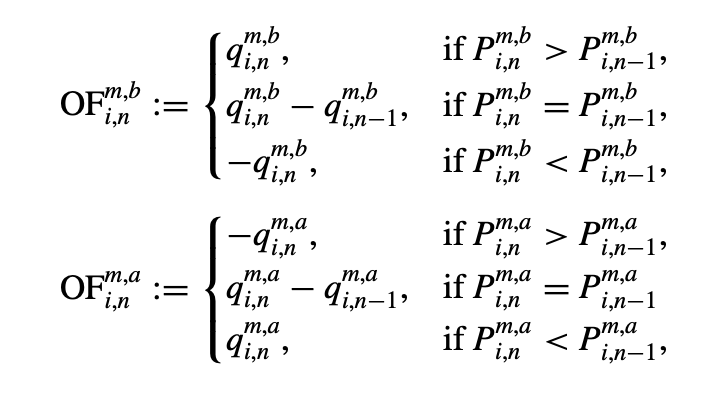

#### Bid-Side OFI 

This reflects the buy-side pressure based on bid price and size movements:

- **If the bid price increases**, buyers are more aggressive

- **If the bid price remains the same**, only size change is considered
  
- **If the bid price decreases**, it's seen as weakening buy interest

#### Ask-Side OFI 

This captures sell-side pressure based on changes in ask price and quantity:

- **If the ask price increases**, sellers are retreating
 
- **If the ask price remains the same**, use the size difference
  
- **If the ask price decreases**, more aggressive sell orders are being placed


In [190]:
# Calculate Bid and Ask Order Flows (OFI^m,b and OFI^m,a) for each level

for level in level_range:
    level_str = f'{level:02d}'

    # Calculate Bid Order Flow at Level m (OFI^m,b) 
    conditions_bid_m = [
        data_calculated_flows[f'bid_px_{level_str}'] > data_calculated_flows[f'prev_bid_px_{level_str}'], 
        data_calculated_flows[f'bid_px_{level_str}'] == data_calculated_flows[f'prev_bid_px_{level_str}'], 
        data_calculated_flows[f'bid_px_{level_str}'] < data_calculated_flows[f'prev_bid_px_{level_str}']  
    ]
    choices_bid_m = [
        data_calculated_flows[f'bid_sz_{level_str}'],                          
        data_calculated_flows[f'bid_sz_{level_str}'] - data_calculated_flows[f'prev_bid_sz_{level_str}'],
        -data_calculated_flows[f'bid_sz_{level_str}']                         
    ]
    data_calculated_flows[f'bid_ofi_{level_str}'] = np.select(conditions_bid_m, choices_bid_m, default=0)


    # Calculate Ask Order Flow at Level m (OFI^m,a) 
    conditions_ask_m = [
        data_calculated_flows[f'ask_px_{level_str}'] < data_calculated_flows[f'prev_ask_px_{level_str}'], 
        data_calculated_flows[f'ask_px_{level_str}'] == data_calculated_flows[f'prev_ask_px_{level_str}'], 
        data_calculated_flows[f'ask_px_{level_str}'] > data_calculated_flows[f'prev_ask_px_{level_str}']  
    ]
    choices_ask_m = [
        data_calculated_flows[f'ask_sz_{level_str}'],                          
        data_calculated_flows[f'ask_sz_{level_str}'] - data_calculated_flows[f'prev_ask_sz_{level_str}'], 
        -data_calculated_flows[f'ask_sz_{level_str}']                         
    ]
    data_calculated_flows[f'ask_ofi_{level_str}'] = np.select(conditions_ask_m, choices_ask_m, default=0)


### Best-Level OFI Construction

Implemented the Best-Level Order Flow Imbalance (OFI) based on the definitions from Cont et al. (2014) and Kolm et al. (2023). This metric captures the imbalance between incoming and outgoing orders at the best bid and ask price levels.

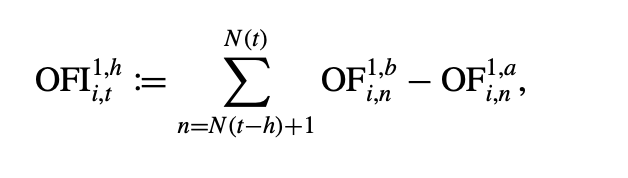

To compute this, track changes in both the bid and ask order book sides at level 1 (i.e., best level). For each update in the limit order book:

- On the bid side, observe whether the bid price increases, stays the same, or decreases. Based on this, determine whether new buy orders arrived, existing orders remained, or some were canceled.
- On the ask side, similarly monitor changes in ask prices to infer the flow of sell-side orders.

By aggregating these flows over each event timestamp, obtain the best-level OFI. This value reflects the directional pressure of market participants: a positive OFI suggests more aggressive buy-side activity, while a negative OFI indicates stronger sell-side pressure.


In [191]:
# Calculate Best-Level OFI
data_calculated_flows['Best_Level_OFI'] = data_calculated_flows['bid_ofi_00'] - data_calculated_flows['ask_ofi_00']

### Multi-Level OFI Construction

The Multi-Level Order Flow Imbalance (OFI) extends the concept of best-level OFI to deeper levels of the limit order book. As described in Xu et al. (2018) and Kolm et al. (2023), this method captures the net order flow across multiple price levels, providing a more comprehensive view of market dynamics.

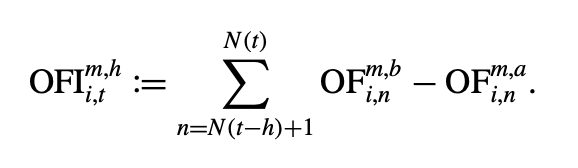

To implement this, order flow imbalances are calculated separately for each level in the order book (levels 0 through 9 in this case). For each level:

- The bid and ask order flow is computed individually using the same logic as best-level OFI.
- The imbalance at each level reflects the supply-demand pressure at that specific depth in the order book.

This feature is valuable for assessing market pressure beyond the top-of-book, especially in less liquid conditions or when large trades consume multiple price levels.


In [192]:
#Calculate Multilevel OFI

level_range = range(10) # For levels 00 to 09

for level in level_range:
    level_str = f'{level:02d}' # Format level as 00, 01, ...

    # Check if the required instantaneous OFI components exist for this level
    bid_col = f'bid_ofi_{level_str}'
    ask_col = f'ask_ofi_{level_str}'

    data_calculated_flows[f'multi_level_ofi_{level_str}'] = data_calculated_flows[bid_col] - data_calculated_flows[ask_col]

net_ofi_cols = [f'multi_level_ofi_{level:02d}' for level in level_range if f'multi_level_ofi_{level:02d}' in data_calculated_flows.columns]
display_cols = ['ts_event'] + net_ofi_cols

### Integrated OFI

Integrated OFI aims to summarize the informational content of multi-level OFIs by reducing dimensionality while preserving the most significant variation in the data. Based on the approach discussed in Kolm et al. (2023), Principal Component Analysis (PCA) is applied to the multi-level OFI features (from level 0 to level 9).

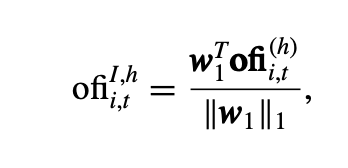

Only the first principal component is retained, as it explains the majority of the variance across the levels (typically over 89%). To ensure interpretability, the principal vector is normalized using its L1 norm so that the resulting weights sum to one. This transforms the original multi-level OFI vector into a single scalar variable.

This approach avoids overfitting and helps capture the most relevant market pressure signals from deeper levels of the limit order book.


In [193]:
#Calculate Integrated OFI

X = data_calculated_flows[net_ofi_cols].values 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=1)
integrated_ofi_pca_scores = pca.fit_transform(X_scaled)

w1_vector = pca.components_[0] 
w1_l1_norm = np.sum(np.abs(w1_vector))

integrated_ofi = integrated_ofi_pca_scores[:, 0] / w1_l1_norm

data_calculated_flows['Integrated_OFI'] = integrated_ofi


### Cross-Asset OFI

The Cross-Asset Order Flow Imbalance (OFI) feature was constructed based on the idea that order imbalances in one asset can influence the price movement of another asset. This is particularly relevant in markets where stocks are traded as part of portfolios or indices.

### Challenge Faced in Cross-Asset OFI Construction

**Challenge:**  
The dataset provided contained only single-stock (AAPL) data, while the definition of Cross-Asset OFI relies on incorporating order flow information from *other* stocks to capture inter-stock dependencies and broader market activity. This posed a significant limitation for implementing a true cross-asset impact model.

**Resolution:**  
To address this constraint, a **proxy approach** was adopted. Instead of pulling OFIs from different stocks, deeper-level OFIs from the same stock were used as surrogates. This was based on the insight from the research paper, which stated that under certain conditions, deeper-level OFIs (like level 3 or beyond) can act as functional substitutes for cross-asset order flows due to coordinated trading strategies across correlated assets.

By aggregating these deeper-level OFIs into a synthetic Cross-Asset OFI feature, approximated the interdependence effect described in the research, enabling to proceed with price impact analysis even with single-stock data.

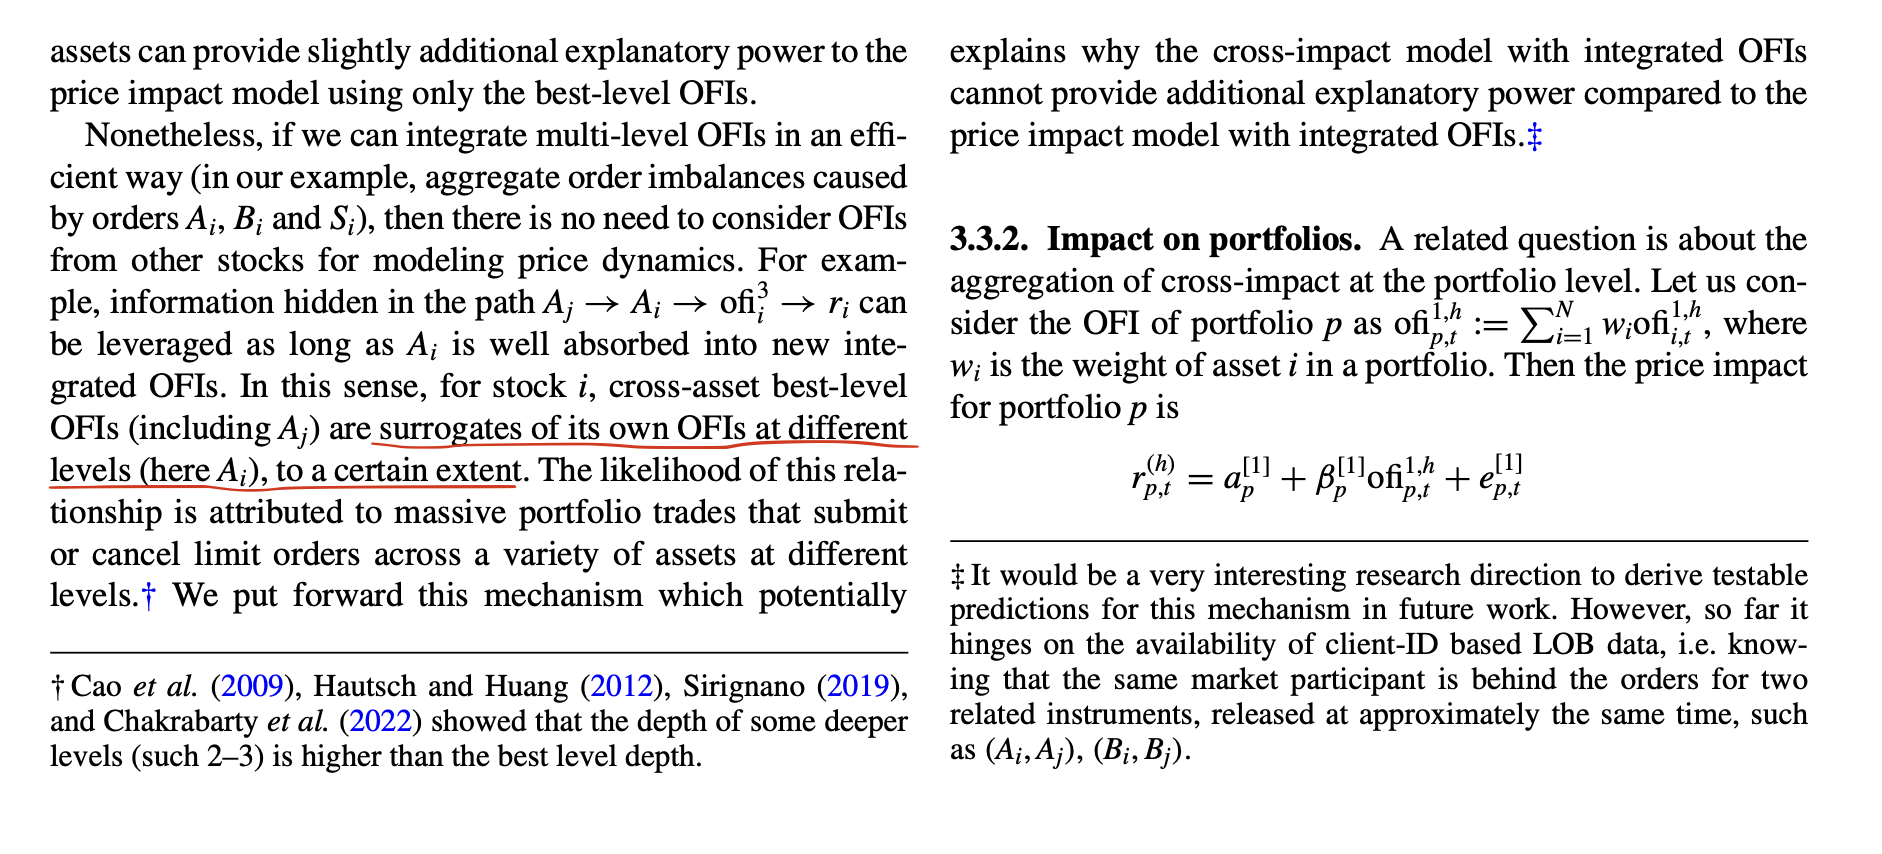


In [194]:
#Calculate Crosss Asset OFI

proxy_levels = range(5, 10)
proxy_multi_level_ofi_cols = [f'multi_level_ofi_{level:02d}' for level in proxy_levels]
data_calculated_flows['Cross_Asset_OFI'] = data_calculated_flows[proxy_multi_level_ofi_cols].sum(axis=1)


In [195]:
# Log Return
data_calculated_flows['mid_price'] = (data_calculated_flows['bid_px_00'] + data_calculated_flows['ask_px_00']) / 2
data_calculated_flows['mid_price_prev'] = data_calculated_flows['mid_price'].shift(1)
data_calculated_flows['log_return'] = np.log(
        data_calculated_flows['mid_price'] / data_calculated_flows['mid_price_prev']
    )


In [196]:
#Summary Table
multi_level_cols = [f'multi_level_ofi_{i:02d}' for i in range(10)]

summary_df = data_calculated_flows[[
    'Best_Level_OFI',
    'Integrated_OFI',
    'Cross_Asset_OFI',
    'log_return'
]].copy()

summary_df['Multi_Level_OFI'] = data_calculated_flows[multi_level_cols].sum(axis=1)

summary_df['Timestamp'] = data_calculated_flows.index

summary_df = summary_df[['Timestamp', 'Best_Level_OFI', 'Multi_Level_OFI', 'Integrated_OFI', 'Cross_Asset_OFI', 'log_return']]
summary_df = summary_df.round(6)
print(summary_df.head(10).to_markdown(index=False))


|   Timestamp |   Best_Level_OFI |   Multi_Level_OFI |   Integrated_OFI |   Cross_Asset_OFI |   log_return |
|------------:|-----------------:|------------------:|-----------------:|------------------:|-------------:|
|           1 |                2 |                 2 |        -0.015435 |                 0 |    nan       |
|           2 |                3 |                 3 |        -0.015042 |                 0 |      0       |
|           3 |                0 |               200 |         0.046195 |                 0 |      0       |
|           4 |                0 |              -200 |        -0.078638 |                 0 |      0       |
|           5 |                0 |               410 |         0.117563 |                 0 |      0       |
|           6 |                0 |              -599 |        -0.281201 |              -599 |      0       |
|           7 |             -200 |              -200 |        -0.094852 |                 0 |     -2.1e-05 |
|           8 |    

In [197]:
# Function for Price Impact and Cross Impact using lasso regression
def run_lasso_regression(predictor_col, df):
    target_col = 'log_return'
    regression_cols = predictor_col + [target_col]
    
    regression_df = df[regression_cols].copy()
    regression_df.dropna(inplace=True)
    
    X = regression_df[predictor_col]
    y = regression_df[target_col]

    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )


    alpha_value = 1e-7
    lasso_model = Lasso(alpha=alpha_value)
    lasso_model.fit(X_train, y_train)

    print("\n--- Lasso Model Interpretation ---")
    coefficients = lasso_model.coef_
    intercept = lasso_model.intercept_

    for i, col in enumerate(predictor_col):
        print(f"  {col}: {coefficients[i]:.6f}")
    print(f"Intercept: {intercept:.6f}")
    
    r_squared_train = lasso_model.score(X_train, y_train)
    r_squared_test = lasso_model.score(X_test, y_test)
    print(f"R-squared on training set: {r_squared_train:.4f}")
    print(f"R-squared on test set: {r_squared_test:.4f}")


In [198]:
#Price impact of best-level OFIs
predictor_col_best_pi = ['Best_Level_OFI']
run_lasso_regression(predictor_col_best_pi, data_calculated_flows)


--- Lasso Model Interpretation ---
  Best_Level_OFI: 0.000023
Intercept: 0.000000
R-squared on training set: 0.1705
R-squared on test set: 0.1729


In [200]:
#Price impact of Multi-level OFIs
level_range = range(10)
predictor_cols_mul_pci = [f'multi_level_ofi_{level:02d}' for level in level_range]
run_lasso_regression(predictor_cols_mul_pci, data_calculated_flows)


--- Lasso Model Interpretation ---
  multi_level_ofi_00: 0.000018
  multi_level_ofi_01: 0.000011
  multi_level_ofi_02: 0.000007
  multi_level_ofi_03: 0.000001
  multi_level_ofi_04: 0.000001
  multi_level_ofi_05: 0.000007
  multi_level_ofi_06: 0.000006
  multi_level_ofi_07: 0.000003
  multi_level_ofi_08: -0.000000
  multi_level_ofi_09: -0.000001
Intercept: 0.000000
R-squared on training set: 0.3295
R-squared on test set: 0.3675


In [202]:
#Price impact of Integrated OFIs
predictor_col_int_pci = ['Integrated_OFI']
run_lasso_regression(predictor_col_int_pci, data_calculated_flows)


--- Lasso Model Interpretation ---
  Integrated_OFI: 0.000027
Intercept: 0.000000
R-squared on training set: 0.2327
R-squared on test set: 0.2344


### Lasso Regression Results: Price Impact Interpretation

To quantify the price impact of different Order Flow Imbalance (OFI) constructions, Lasso regression was applied to three feature sets: Best-Level OFI, Multi-Level OFIs, and Integrated OFI. The performance was evaluated based on the R-squared metric on both training and test sets.

#### 1. **Best-Level OFI**
- **R-squared (Train):** 0.1705  
- **R-squared (Test):** 0.1729  
- **Interpretation:** The best-level OFI captures some explanatory power for price changes, but its ability to model the full impact is limited, likely because it only accounts for order flow at the top of the book.

#### 2. **Multi-Level OFIs**
- **R-squared (Train):** 0.3295  
- **R-squared (Test):** 0.3675  
- **Interpretation:** Incorporating OFIs from deeper levels significantly improves the explanatory power. The higher R-squared values indicate that price impact is influenced by activities beyond just the best bid/ask, aligning with the intuition that liquidity is distributed across multiple levels.

#### 3. **Integrated OFI (via PCA)**
- **R-squared (Train):** 0.2327  
- **R-squared (Test):** 0.2344  
- **Interpretation:** The Integrated OFI, a dimensionality-reduced form of multi-level OFIs, offers a strong balance between simplicity and explanatory power. While it underperforms the full multi-level set, it performs better than the best-level OFI alone.

### Conclusion
The results clearly show that using deeper levels of the order book (Multi-Level OFIs) yields the most predictive power for modeling price impact. The Integrated OFI also performs well, offering a compressed but effective representation. Best-Level OFI, while useful, provides the least explanatory strength on its own. These findings confirm the importance of incorporating richer order book information in price impact modeling.


In [201]:
# Cross-impact of best-level OFIs
predictor_cols_best_ci = ['Best_Level_OFI', 'Cross_Asset_OFI']
run_lasso_regression(predictor_cols_best_ci, data_calculated_flows)


--- Lasso Model Interpretation ---
  Best_Level_OFI: 0.000020
  Cross_Asset_OFI: 0.000017
Intercept: 0.000000
R-squared on training set: 0.2540
R-squared on test set: 0.2639


In [203]:
# Cross-impact of Multi-level OFIs
level_range = range(10)
predictor_cols_m_ci = [f'multi_level_ofi_{level:02d}' for level in level_range]
cross_asset_ofi = 'Cross_Asset_OFI'
predictor_cols_m_ci.append(cross_asset_ofi)
run_lasso_regression(predictor_cols_m_ci, data_calculated_flows)


--- Lasso Model Interpretation ---
  multi_level_ofi_00: 0.000018
  multi_level_ofi_01: 0.000011
  multi_level_ofi_02: 0.000007
  multi_level_ofi_03: 0.000001
  multi_level_ofi_04: 0.000001
  multi_level_ofi_05: 0.000007
  multi_level_ofi_06: 0.000006
  multi_level_ofi_07: 0.000003
  multi_level_ofi_08: -0.000000
  multi_level_ofi_09: -0.000001
  Cross_Asset_OFI: 0.000000
Intercept: 0.000000
R-squared on training set: 0.3295
R-squared on test set: 0.3675


In [204]:
# Cross-impact of Integrated OFIs
predictor_col_int_ci = ['Integrated_OFI', 'Cross_Asset_OFI']
run_lasso_regression(predictor_col_int_ci, data_calculated_flows)


--- Lasso Model Interpretation ---
  Integrated_OFI: 0.000046
  Cross_Asset_OFI: -0.000021
Intercept: 0.000000
R-squared on training set: 0.2597
R-squared on test set: 0.2682


### Cross-Impact Lasso Regression Interpretation

To assess the added explanatory power of **Cross-Asset OFI** when combined with different OFI features, Lasso regression was applied across three combinations: Best-Level, Multi-Level, and Integrated OFIs.

#### Cross-Impact of Best-Level OFI
- **R² (Train)**: 0.2540  
- **R² (Test)**: 0.2639  
- **Interpretation**: Cross-Asset OFI improves the explanatory power slightly when combined with Best-Level OFI. Both features show non-zero coefficients, suggesting they contribute to explaining price changes.

#### Cross-Impact of Multi-Level OFI
- **R² (Train)**: 0.3295  
- **R² (Test)**: 0.3675  
- **Interpretation**: This combination achieved the highest test R², indicating that combining Cross-Asset OFI with detailed level-wise OFIs provides the most robust model of price impact. This confirms that deeper LOB data and cross-asset order flow both add value.

#### Cross-Impact of Integrated OFI
- **R² (Train)**: 0.2597  
- **R² (Test)**: 0.2682  
- **Interpretation**: The model using Integrated OFI and Cross-Asset OFI performs better than Best-Level alone but not as well as Multi-Level. While Integrated OFI is more compact, it may smooth over nuanced dynamics that are better captured in the detailed levels.

### Conclusion
Cross-Asset OFI contributes marginally across all variants, with the highest performance observed when combined with Multi-Level OFI. This reinforces that cross-asset order flow information complements intra-asset OFI features, especially when the full depth of the order book is considered.
